In [33]:
import warnings
warnings.filterwarnings('ignore')
import sys
print(sys.executable)

C:\Users\aksha\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
import pandas as pd
from prophet import Prophet

#### Time series of the log daily page views for the Wikipedia page for Peyton Manning. 

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
df.head()

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


### Quick Start

In [5]:
m = Prophet()
m.fit(df)

19:44:06 - cmdstanpy - INFO - Chain [1] start processing
19:44:07 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [7]:
forecast = m.predict(future)
forecast[['ds','yhat','yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.206964,7.472184,8.922957
3266,2017-01-16,8.531958,7.770367,9.318288
3267,2017-01-17,8.319376,7.611447,9.084267
3268,2017-01-18,8.151991,7.393787,8.861563
3269,2017-01-19,8.163908,7.508555,8.918356


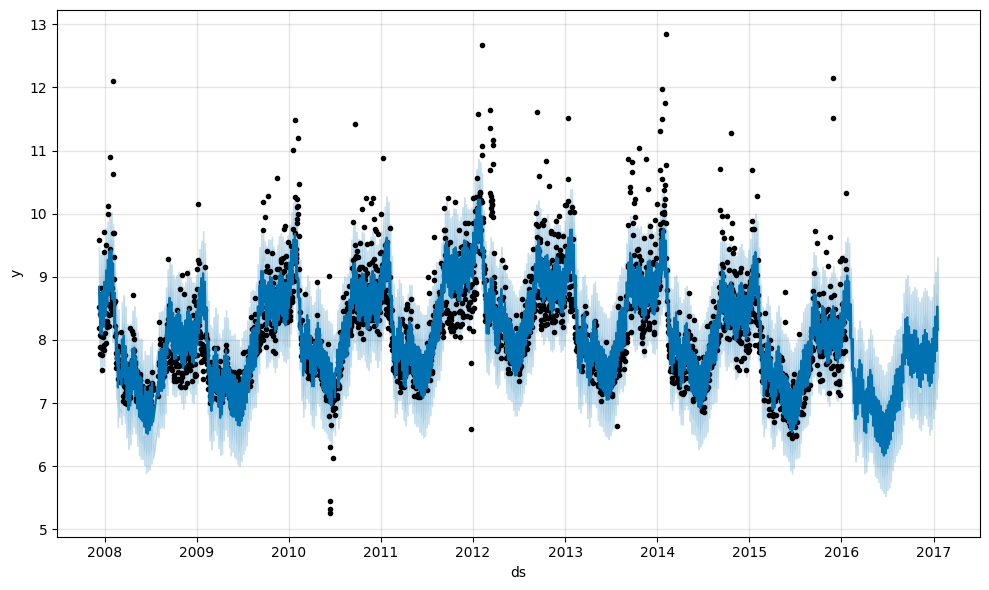

In [9]:
fig1 = m.plot(forecast)

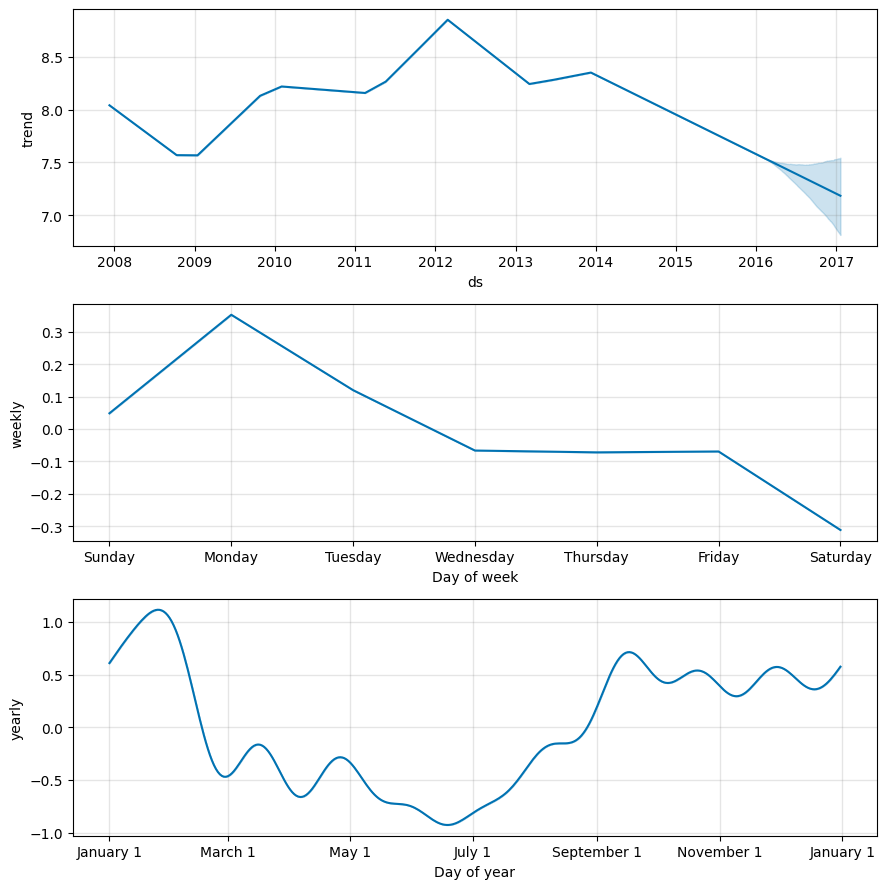

In [10]:
fig2 = m.plot_components(forecast)

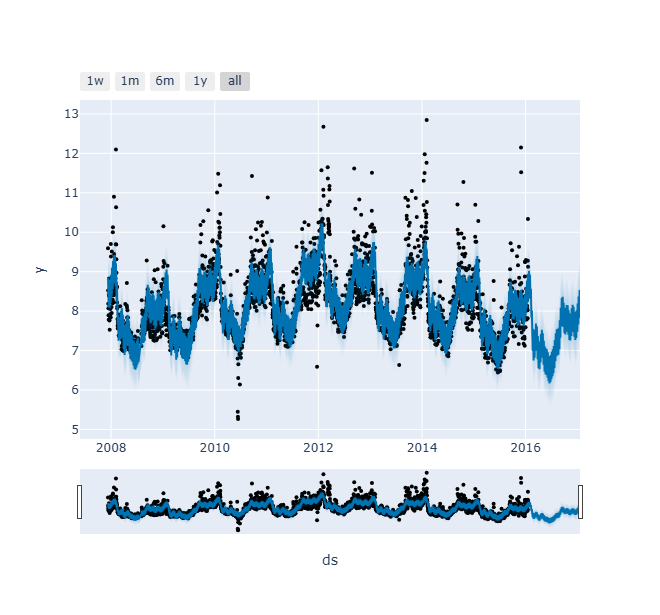

In [12]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

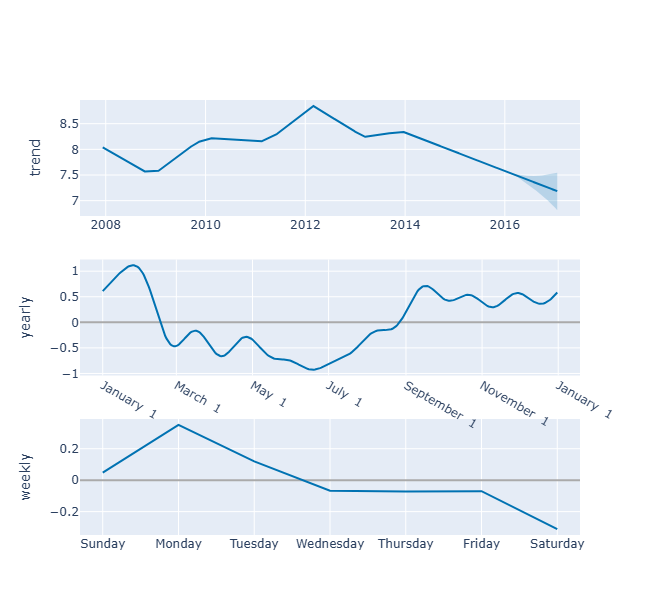

In [13]:
plot_components_plotly(m, forecast)

### Saturating Forecasts

#### The log number of page visits to the R (programming language) page on Wikipedia:

In [ ]:
examples/example_wp_log_R.csv

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_R.csv')
df.head()

,ds,y
0,2008-01-30,5.976351
1,2008-01-16,6.049733
2,2008-01-17,6.011267
3,2008-01-14,5.953243
4,2008-01-15,5.910797


In [29]:
df['cap'] = 8.5

In [30]:
m = Prophet(growth = 'logistic')
m.fit(df)

DEBUG	Task(Task-4) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-4) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-4) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-4) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpjpdxwkl9\k1_fhcm6.json
DEBUG	Task(Task-4) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpjpdxwkl9\v_t45338.json
DEBUG	Task(Task-4) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-4) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-4) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=92630', 'data', 'file=C:\\Users\\aksha\\

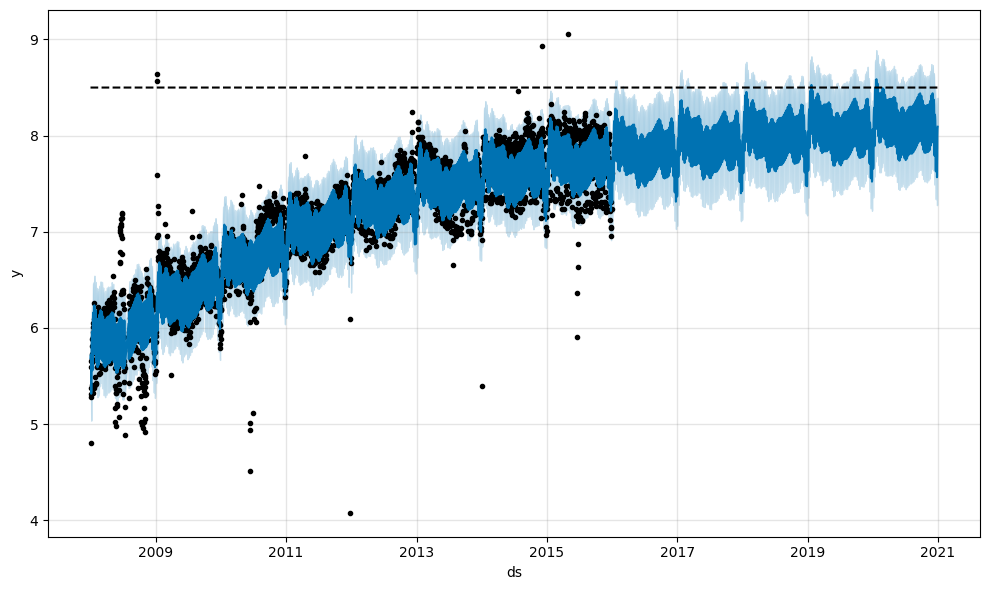

In [31]:
future = m.make_future_dataframe(periods=1826)
future['cap'] =  8.5
fcst = m.predict(future)
fig = m.plot(fcst)

DEBUG	Task(Task-4) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-4) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-4) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-4) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpjpdxwkl9\ugnrxq2n.json
DEBUG	Task(Task-4) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpjpdxwkl9\0ooslqok.json
DEBUG	Task(Task-4) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-4) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-4) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=26718', 'data', 'file=C:\\Users\\aksha\\

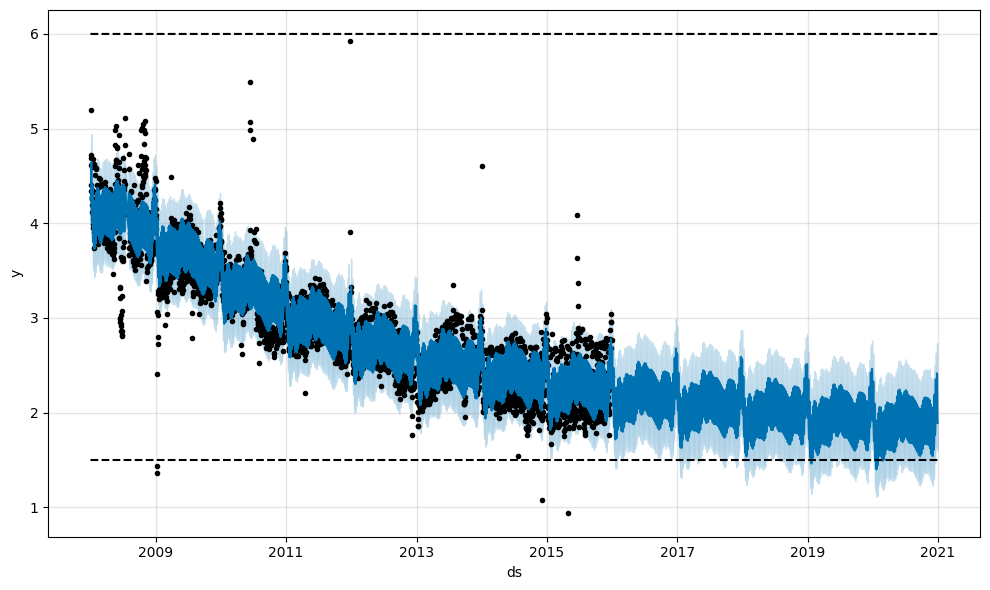

In [32]:
df['y'] = 10 - df['y']
df['cap'] = 6
df['floor'] = 1.5
future['cap'] = 6
future['floor'] = 1.5
m = Prophet(growth='logistic')
m.fit(df)
fcst = m.predict(future)
fig = m.plot(fcst)